# AI Weather Classification System

## 1. IMPORT LIBRARIES

In [1]:
# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import joblib
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

print("Libraries loaded successfully")

2026-05-17 20:21:56.857632: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779049317.104257      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779049317.185515      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779049317.851510      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779049317.851555      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779049317.851557      57 computation_placer.cc:177] computation placer alr

Libraries loaded successfully


## Remove Warnings

In [3]:
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

## 2. LOAD DATASET

In [4]:
# =========================================================
# 2. LOAD DATASET
# =========================================================

df = pd.read_csv(
    '/kaggle/input/datasets/nikhil7280/weather-type-classification/weather_classification_data.csv'
)

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 13200 rows, 11 columns


## 3. CLEAN COLUMN NAMES

In [6]:
# =========================================================
# 3. CLEAN COLUMN NAMES
# =========================================================

df.columns = df.columns.str.strip()

print("\nColumns:")
print(df.columns.tolist())


Columns:
['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season', 'Visibility (km)', 'Location', 'Weather Type']


## 4. FEATURE SELECTION

In [7]:
# =========================================================
# 4. FEATURE SELECTION
# KEEP ONLY SENSOR-AVAILABLE FEATURES
# =========================================================

print("\n=== Feature Selection ===")

print("Keeping only Wokwi sensor compatible features")

selected_features = [

    'Temperature',
    'Humidity',
    'Wind Speed',
    'Precipitation (%)',
    'Atmospheric Pressure',
    'UV Index',
    'Visibility (km)'
]

target_column = 'Weather Type'

df_model = df[selected_features + [target_column]].copy()

print("\nSelected Features:")
print(df_model.columns.tolist())

print(f"\nReduced Dataset Shape: {df_model.shape}")


=== Feature Selection ===
Keeping only Wokwi sensor compatible features

Selected Features:
['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)', 'Weather Type']

Reduced Dataset Shape: (13200, 8)


# 5. Exploratory Data Analysis (EDA)

In [8]:
# =========================================================
# 5. EDA
# =========================================================

print("\n=== Dataset Info ===")
df_model.info()

print("\n=== Statistical Summary ===")
print(df_model.describe())

print("\n=== Missing Values ===")
print(df_model.isnull().sum())

print("\n=== Target Class Distribution ===")
print(df_model[target_column].value_counts())


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Atmospheric Pressure  13200 non-null  float64
 5   UV Index              13200 non-null  int64  
 6   Visibility (km)       13200 non-null  float64
 7   Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(1)
memory usage: 825.1+ KB

=== Statistical Summary ===
        Temperature      Humidity    Wind Speed  Precipitation (%)  \
count  13200.000000  13200.000000  13200.000000       13200.000000   
mean      19.127576     68.710833      9.832197          53.644394   
std       17.386327     20.194248      6.908704          

### 5.1 TARGET DISTRIBUTION

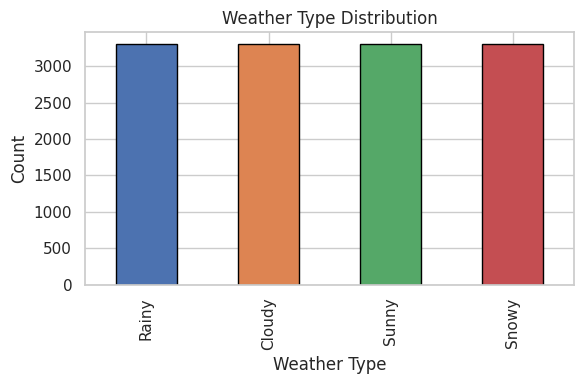

In [9]:
# =========================================================
# TARGET DISTRIBUTION
# =========================================================

plt.figure(figsize=(6,4))

df_model[target_column].value_counts().plot(

    kind='bar',

    color=['#4C72B0','#DD8452','#55A868','#C44E52'],

    edgecolor='black'
)

plt.title('Weather Type Distribution')

plt.xlabel('Weather Type')

plt.ylabel('Count')

plt.tight_layout()

plt.show()

### 5.2 FEATURE DISTRIBUTIONS

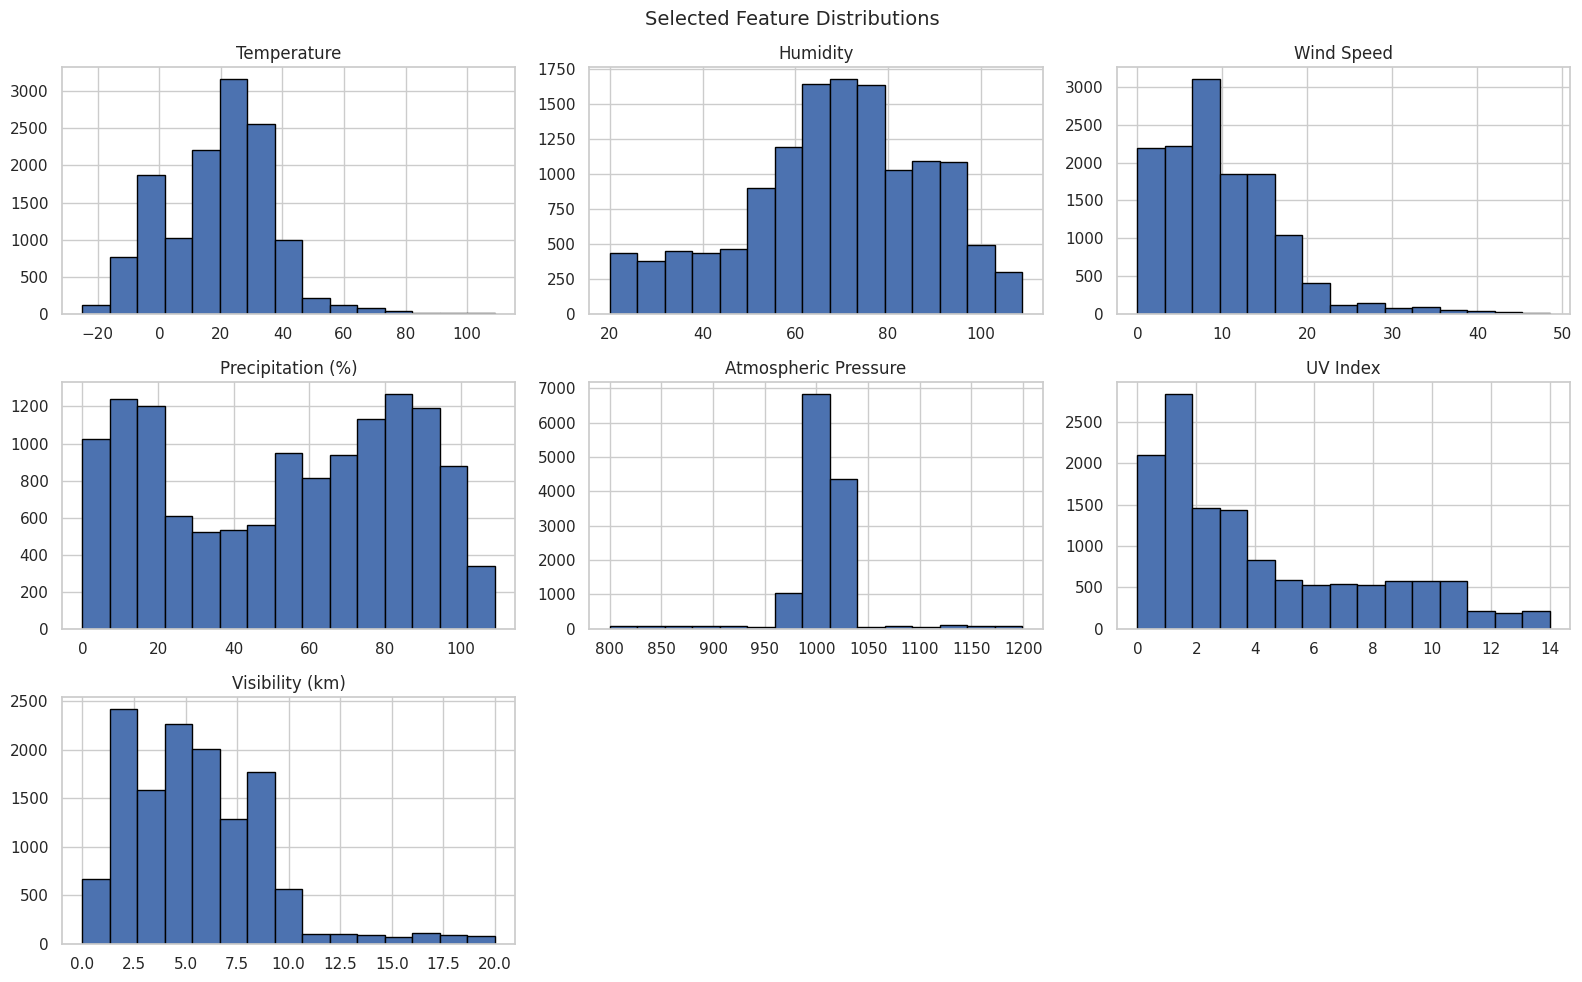

In [10]:
# =========================================================
# FEATURE DISTRIBUTIONS
# =========================================================

df_model[selected_features].hist(

    bins=15,

    figsize=(16,10),

    edgecolor='black'
)

plt.suptitle(
    'Selected Feature Distributions',
    fontsize=14
)

plt.tight_layout()

plt.show()

### 5.3 CORRELATION HEATMAP

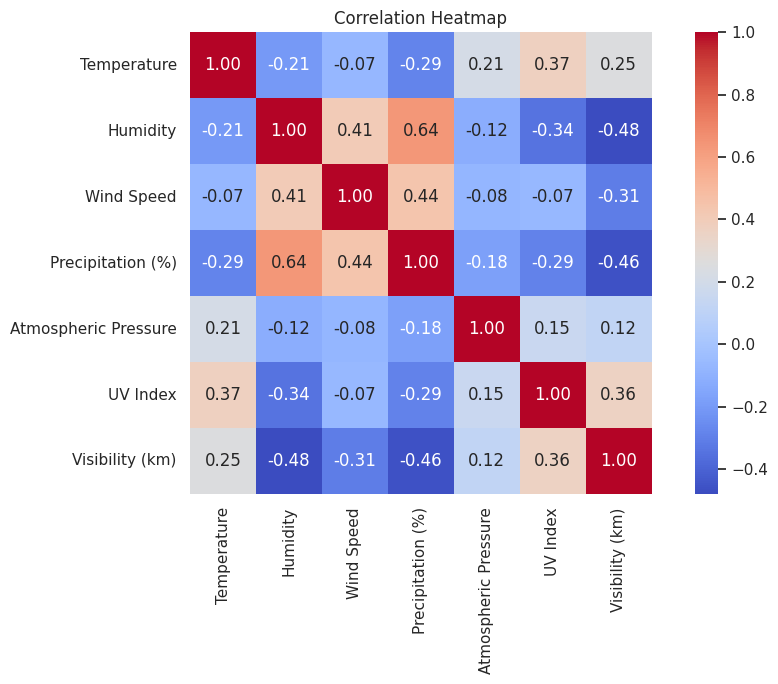

In [11]:
# =========================================================
# CORRELATION HEATMAP
# =========================================================

plt.figure(figsize=(10,7))

corr = df_model[selected_features].corr()

sns.heatmap(

    corr,

    annot=True,

    fmt='.2f',

    cmap='coolwarm',

    square=True
)

plt.title('Correlation Heatmap')

plt.tight_layout()

plt.show()

### 5.4 BOXPLOTS

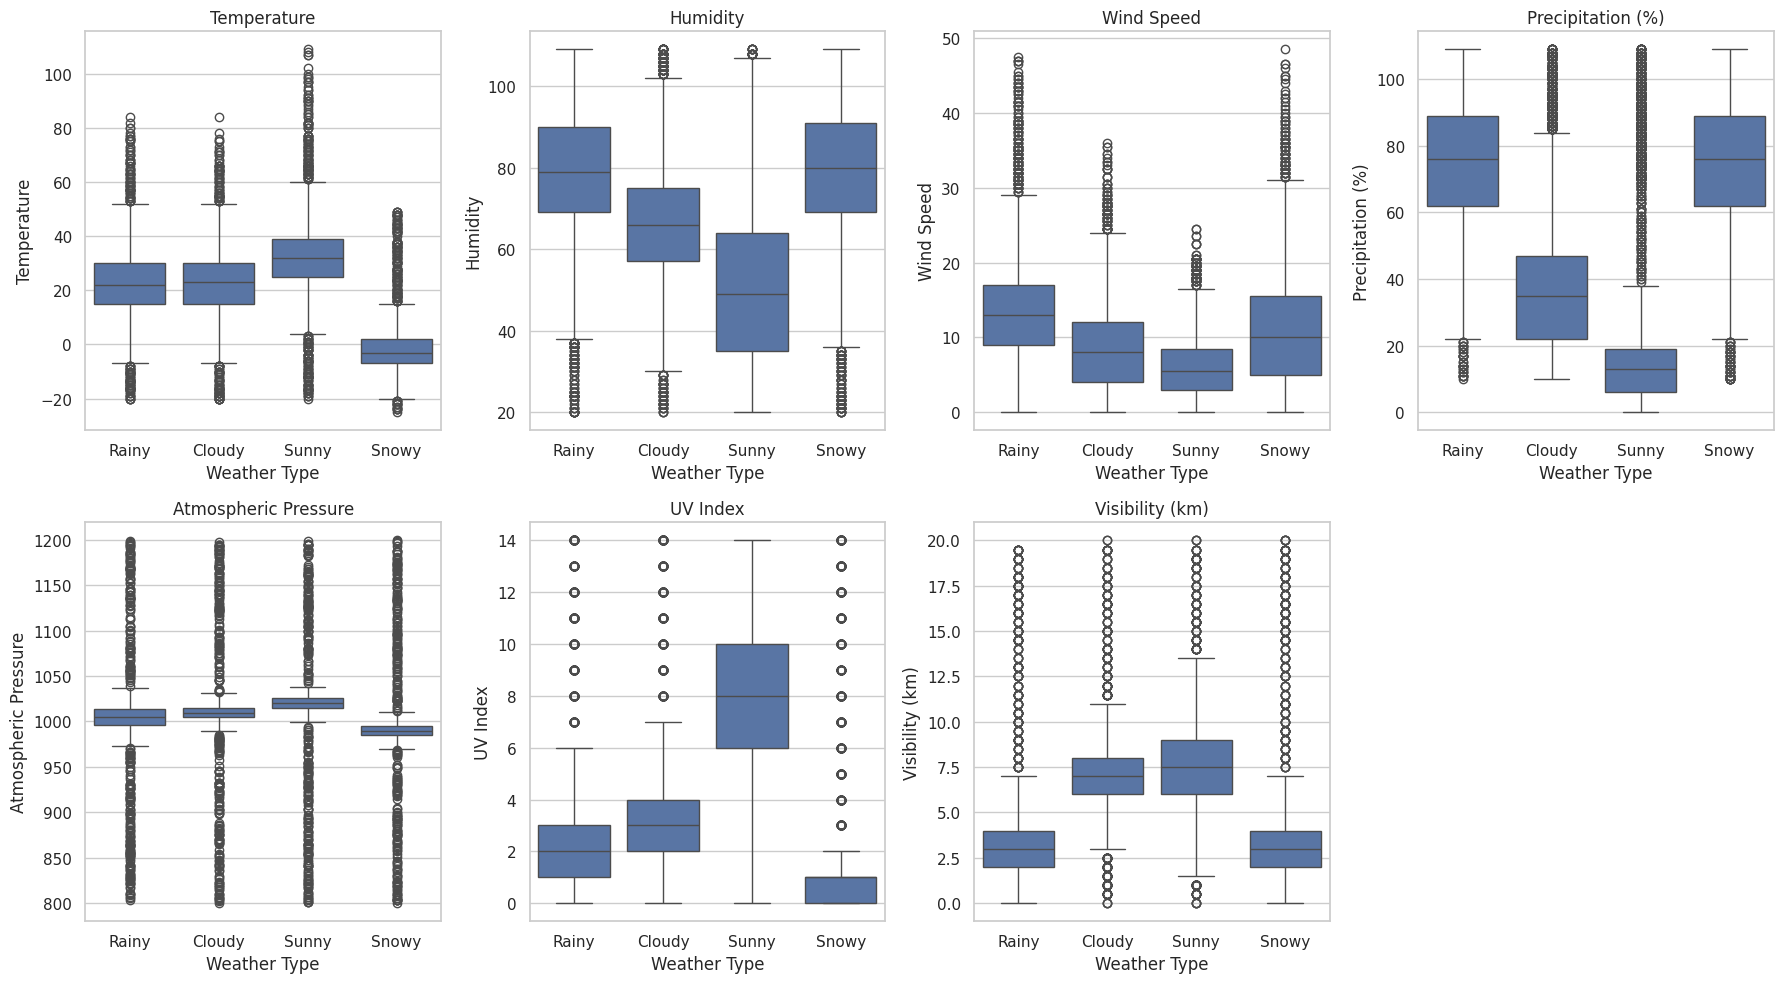

In [12]:
# =========================================================
# BOXPLOTS
# =========================================================

fig, axes = plt.subplots(2,4, figsize=(18,10))

axes = axes.flatten()

for i, col in enumerate(selected_features):

    sns.boxplot(

        x=target_column,

        y=col,

        data=df_model,

        ax=axes[i]
    )

    axes[i].set_title(col)

axes[-1].set_visible(False)

plt.tight_layout()

plt.show()

### 6. PREPROCESSING

In [13]:
# =========================================================
# 6. PREPROCESSING
# =========================================================

label_encoder = LabelEncoder()

df_model['Weather Type Encoded'] = label_encoder.fit_transform(
    df_model[target_column]
)

print("\n=== Label Encoding Mapping ===")

for i, cls in enumerate(label_encoder.classes_):

    print(f"{i} → {cls}")


=== Label Encoding Mapping ===
0 → Cloudy
1 → Rainy
2 → Snowy
3 → Sunny


### 6.1 FEATURES AND TARGET

In [14]:
# =========================================================
# FEATURES AND TARGET
# =========================================================

X = df_model[selected_features].values

y = df_model['Weather Type Encoded'].values

### 6.2 SCALE FEATURES

In [15]:
# =========================================================
# SCALE FEATURES
# =========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\n=== SCALER MEAN VALUES ===")
print(scaler.mean_)

print("\n=== SCALER SCALE VALUES ===")
print(scaler.scale_)


=== SCALER MEAN VALUES ===
[  19.12757576   68.71083333    9.83219697   53.64439394 1005.82789621
    4.00575758    5.46291667]

=== SCALER SCALE VALUES ===
[17.385668   20.19348314  6.90844244 31.94533065 37.1981796   3.85645428
  3.3713712 ]


### 6.3 TRAIN TEST SPLIT

In [16]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print(f"\nTrain Size : {X_train.shape[0]}")
print(f"Test Size  : {X_test.shape[0]}")


Train Size : 10560
Test Size  : 2640


## 7. TRADITIONAL ML MODELS

In [18]:
# =========================================================
# 7. TRADITIONAL ML MODELS
# =========================================================

class_names = list(label_encoder.classes_)

def evaluate_model(name, model):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    print(f"\n{'='*60}")
    print(f"Model : {name}")
    print(f"{'='*60}")

    print(f"Accuracy  : {acc*100:.2f}%")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nClassification Report:\n")

    print(

        classification_report(
            y_test,
            y_pred,
            target_names=class_names
        )
    )

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=class_names
    )

    disp.plot(cmap='Blues', colorbar=False)

    plt.title(f'Confusion Matrix — {name}')

    plt.tight_layout()

    plt.show()

    return acc, precision, recall, f1

results = {}

## 7.1 Logistic Regression


Model : Logistic Regression
Accuracy  : 86.02%
Precision : 0.8603
Recall    : 0.8602
F1 Score  : 0.8600

Classification Report:

              precision    recall  f1-score   support

      Cloudy       0.84      0.81      0.83       660
       Rainy       0.84      0.88      0.86       660
       Snowy       0.91      0.91      0.91       660
       Sunny       0.86      0.84      0.85       660

    accuracy                           0.86      2640
   macro avg       0.86      0.86      0.86      2640
weighted avg       0.86      0.86      0.86      2640



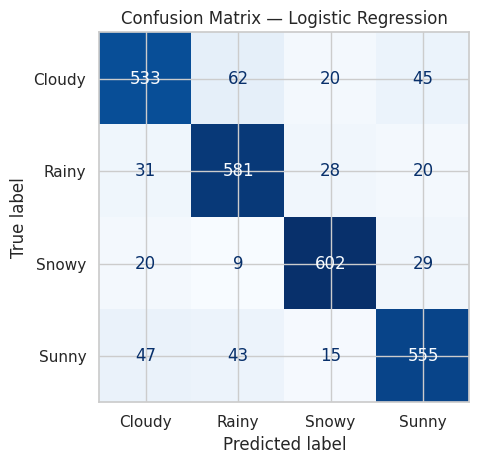

In [19]:
# =========================================================
# LOGISTIC REGRESSION
# =========================================================

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

results['Logistic Regression'] = evaluate_model(
    'Logistic Regression',
    lr
)


### 7.2 DECISION TREE


Model : Decision Tree
Accuracy  : 89.70%
Precision : 0.8993
Recall    : 0.8970
F1 Score  : 0.8971

Classification Report:

              precision    recall  f1-score   support

      Cloudy       0.90      0.84      0.87       660
       Rainy       0.90      0.90      0.90       660
       Snowy       0.96      0.91      0.93       660
       Sunny       0.84      0.94      0.89       660

    accuracy                           0.90      2640
   macro avg       0.90      0.90      0.90      2640
weighted avg       0.90      0.90      0.90      2640



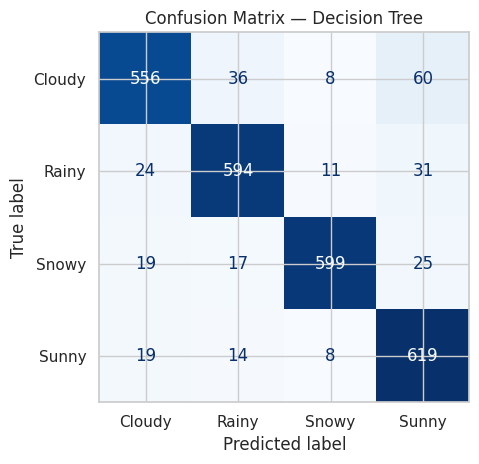

In [20]:
# =========================================================
# DECISION TREE
# =========================================================

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

results['Decision Tree'] = evaluate_model(
    'Decision Tree',
    dt
)


### 7.3 RANDOM FOREST


Model : Random Forest
Accuracy  : 90.68%
Precision : 0.9077
Recall    : 0.9068
F1 Score  : 0.9071

Classification Report:

              precision    recall  f1-score   support

      Cloudy       0.87      0.90      0.88       660
       Rainy       0.91      0.91      0.91       660
       Snowy       0.95      0.91      0.93       660
       Sunny       0.90      0.91      0.91       660

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640



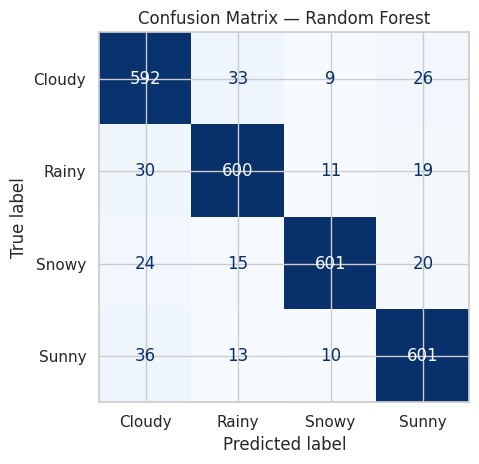

In [21]:
# =========================================================
# RANDOM FOREST
# =========================================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

results['Random Forest'] = evaluate_model(
    'Random Forest',
    rf
)

### 7.4 K-Nearest Neighbours


Model : KNN
Accuracy  : 88.90%
Precision : 0.8911
Recall    : 0.8890
F1 Score  : 0.8895

Classification Report:

              precision    recall  f1-score   support

      Cloudy       0.83      0.88      0.85       660
       Rainy       0.88      0.91      0.89       660
       Snowy       0.95      0.90      0.92       660
       Sunny       0.91      0.87      0.89       660

    accuracy                           0.89      2640
   macro avg       0.89      0.89      0.89      2640
weighted avg       0.89      0.89      0.89      2640



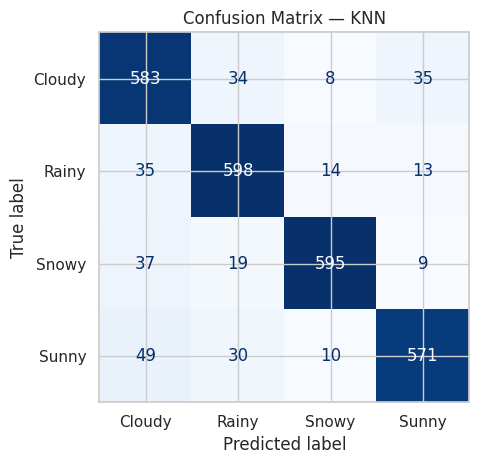

In [22]:
# =========================================================
# KNN
# =========================================================

knn = KNeighborsClassifier(
    n_neighbors=5
)

results['KNN'] = evaluate_model(
    'KNN',
    knn
)


                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.860227   0.860272  0.860227  0.859984
1        Decision Tree  0.896970   0.899340  0.896970  0.897114
2        Random Forest  0.906818   0.907652  0.906818  0.907054
3                  KNN  0.889015   0.891111  0.889015  0.889497


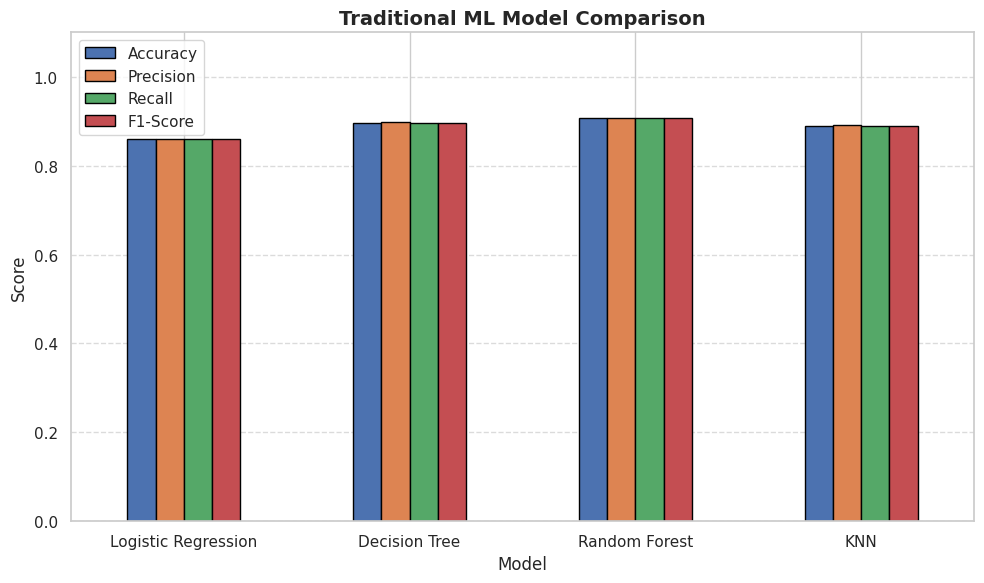

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Create summary table
comparison_df = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],

    'Accuracy': [
        accuracy_score(y_test, lr.predict(X_test)),
        accuracy_score(y_test, dt.predict(X_test)),
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test))
    ],

    'Precision': [
        precision_score(y_test, lr.predict(X_test), average='weighted'),
        precision_score(y_test, dt.predict(X_test), average='weighted'),
        precision_score(y_test, rf.predict(X_test), average='weighted'),
        precision_score(y_test, knn.predict(X_test), average='weighted')
    ],

    'Recall': [
        recall_score(y_test, lr.predict(X_test), average='weighted'),
        recall_score(y_test, dt.predict(X_test), average='weighted'),
        recall_score(y_test, rf.predict(X_test), average='weighted'),
        recall_score(y_test, knn.predict(X_test), average='weighted')
    ],

    'F1-Score': [
        f1_score(y_test, lr.predict(X_test), average='weighted'),
        f1_score(y_test, dt.predict(X_test), average='weighted'),
        f1_score(y_test, rf.predict(X_test), average='weighted'),
        f1_score(y_test, knn.predict(X_test), average='weighted')
    ]
})

print(comparison_df)

# =========================================================
# PLOT COMPARISON
# =========================================================

comparison_df.set_index('Model').plot(

    kind='bar',

    figsize=(10,6),

    edgecolor='black'
)

plt.title(
    'Traditional ML Model Comparison',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('Score')

plt.ylim(0, 1.1)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### 8. TinyML NEURAL NETWORK

In [24]:
# =========================================================
# 8. TinyML NEURAL NETWORK
# =========================================================

print("\n================================================")
print(" TinyML Neural Network")
print("================================================")

# =========================================================
# ONE HOT ENCODING
# =========================================================

y_train_cat = to_categorical(
    y_train,
    num_classes=4
)

y_test_cat = to_categorical(
    y_test,
    num_classes=4
)


 TinyML Neural Network


### 8.1 BUILD TinyML MODEL

In [25]:
# BUILD TinyML MODEL
# =========================================================

tinyml_model = Sequential([

    Dense(
        16,
        activation='relu',
        input_shape=(7,)
    ),

    Dense(
        12,
        activation='relu'
    ),

    Dense(
        4,
        activation='softmax'
    )
])


2026-05-17 20:36:09.924765: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### 8.2 COMPILE MODEL

In [26]:
# =========================================================
# COMPILE MODEL
# =========================================================

tinyml_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

tinyml_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           204 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            52 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 384 (1.50 KB)

 Trainable params: 384 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

### 8.3 TRAIN MODEL

In [27]:
history = tinyml_model.fit(

    X_train,
    y_train_cat,

    epochs=50,

    batch_size=16,

    validation_split=0.2,

    verbose=1
)

Epoch 1/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5397 - loss: 1.0714 - val_accuracy: 0.8665 - val_loss: 0.5279
Epoch 2/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8680 - loss: 0.5049 - val_accuracy: 0.8793 - val_loss: 0.4080
Epoch 3/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8756 - loss: 0.3983 - val_accuracy: 0.8854 - val_loss: 0.3635
Epoch 4/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8876 - loss: 0.3381 - val_accuracy: 0.8873 - val_loss: 0.3372
Epoch 5/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8888 - loss: 0.3174 - val_accuracy: 0.8892 - val_loss: 0.3199
Epoch 6/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8951 - loss: 0.3007 - val_accuracy: 0.8911 - val_loss: 0.3100
Epoch 7/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8940 - loss: 0.2954 - val_accuracy: 0.8935 - val_loss: 0.3018
Epoch 8/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8921 - loss: 0.2884 - val_accuracy: 0.

### 8.4 EVALUATE TinyML MODEL

In [28]:
# =========================================================
# EVALUATE TinyML MODEL
# =========================================================

loss, accuracy = tinyml_model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print(f"\nTinyML Accuracy : {accuracy*100:.2f}%")


TinyML Accuracy : 90.30%


### 8.5 PREDICTIONS

In [29]:
# =========================================================
# PREDICTIONS
# =========================================================

y_pred_prob = tinyml_model.predict(X_test)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Precision : 0.9047
Recall    : 0.9030
F1 Score  : 0.9035


### 8.6 CLASSIFICATION REPORT

In [30]:
# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print("\nClassification Report:\n")

print(

    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)


Classification Report:

              precision    recall  f1-score   support

      Cloudy       0.84      0.90      0.87       660
       Rainy       0.92      0.90      0.91       660
       Snowy       0.93      0.91      0.92       660
       Sunny       0.93      0.89      0.91       660

    accuracy                           0.90      2640
   macro avg       0.90      0.90      0.90      2640
weighted avg       0.90      0.90      0.90      2640



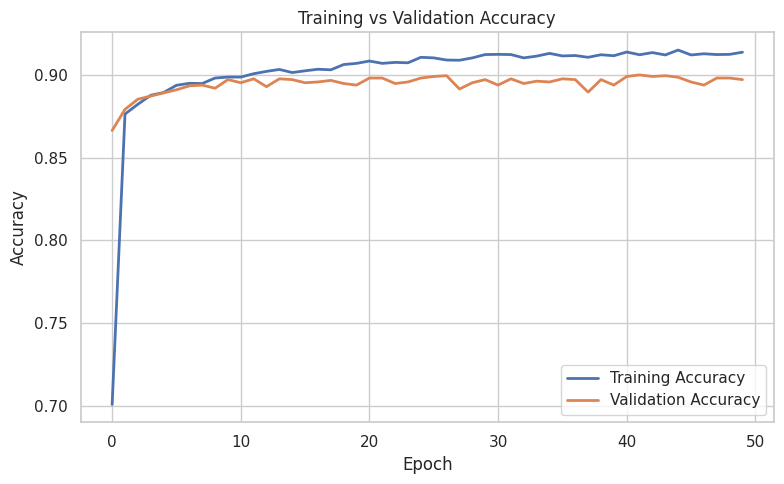

In [31]:
# =========================================================
# TRAINING ACCURACY CURVE
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(

    history.history['accuracy'],

    label='Training Accuracy',

    linewidth=2
)

plt.plot(

    history.history['val_accuracy'],

    label='Validation Accuracy',

    linewidth=2
)

plt.title('Training vs Validation Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


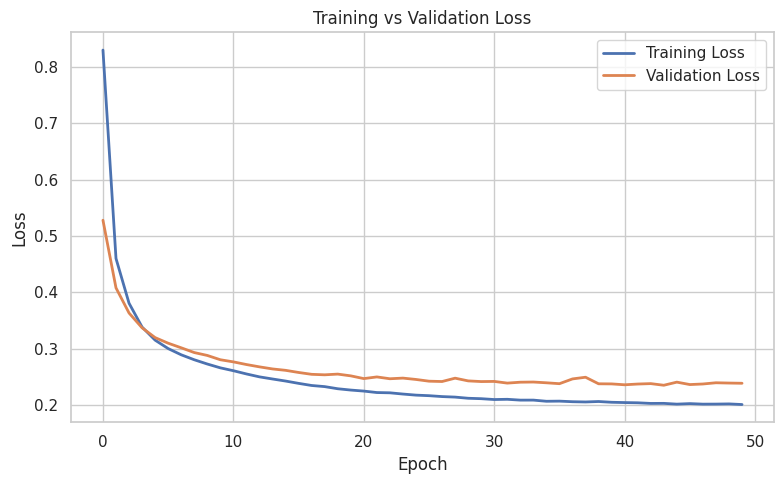

In [32]:
# =========================================================
# TRAINING LOSS CURVE
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(

    history.history['loss'],

    label='Training Loss',

    linewidth=2
)

plt.plot(

    history.history['val_loss'],

    label='Validation Loss',

    linewidth=2
)

plt.title('Training vs Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

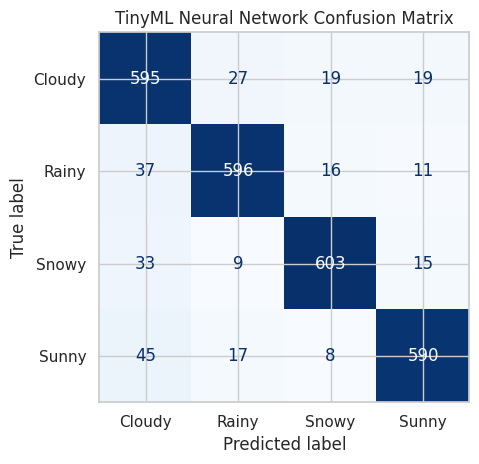

In [33]:
# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    cm,
    display_labels=class_names
)

disp.plot(
    cmap='Blues',
    colorbar=False
)

plt.title('TinyML Neural Network Confusion Matrix')

plt.tight_layout()

plt.show()

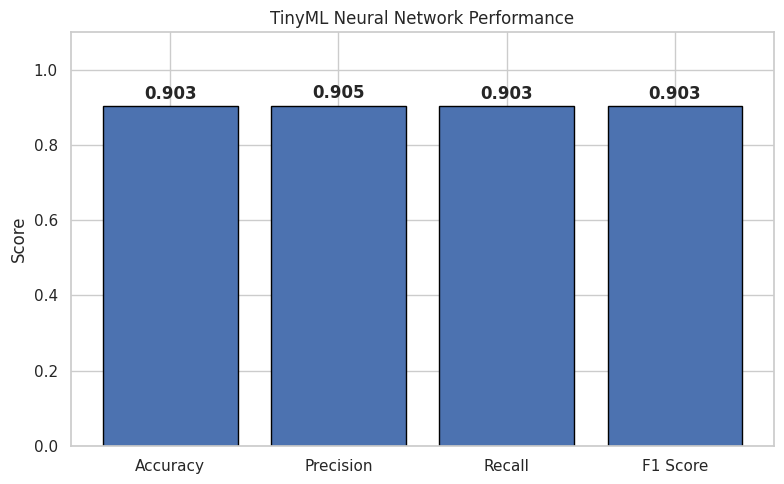

In [34]:
# =========================================================
# TinyML METRICS BAR CHART
# =========================================================

metric_names = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score'
]

metric_values = [
    accuracy,
    precision,
    recall,
    f1
]

plt.figure(figsize=(8,5))

bars = plt.bar(

    metric_names,

    metric_values,

    edgecolor='black'
)

plt.ylim(0,1.1)

for bar, value in zip(
    bars,
    metric_values
):

    plt.text(

        bar.get_x() + bar.get_width()/2,

        value + 0.02,

        f'{value:.3f}',

        ha='center',

        fontweight='bold'
    )

plt.title('TinyML Neural Network Performance')

plt.ylabel('Score')

plt.tight_layout()

plt.show()

## 9. CONVERT TO TFLITE

In [35]:
# =========================================================
# 9. CONVERT TO TFLITE
# =========================================================

converter = tf.lite.TFLiteConverter.from_keras_model(
    tinyml_model
)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

def representative_data_gen():

    for i in range(100):

        sample = X_train[i:i+1].astype(np.float32)

        yield [sample]

converter.representative_dataset = representative_data_gen

tflite_model = converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmpxwvhjjiv/assets


INFO:tensorflow:Assets written to: /tmp/tmpxwvhjjiv/assets


Saved artifact at '/tmp/tmpxwvhjjiv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  134671926619472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134671926620624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134671926619280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134671926617552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134671926621200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134671926616976: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1779050384.379246      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1779050384.379293      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1779050384.384301      57 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32


In [36]:
# =========================================================
# SAVE TFLITE MODEL
# =========================================================

with open(
    "/kaggle/working/weather_classifier.tflite",
    "wb"
) as f:

    f.write(tflite_model)

print("\nweather_classifier.tflite saved!")

print(
    "Model Size:",
    len(tflite_model),
    "bytes"
)


weather_classifier.tflite saved!
Model Size: 4056 bytes


### 10. CONVERT TO HEADER FILE

In [37]:
# =========================================================
# 10. CONVERT TO HEADER FILE
# =========================================================

tflite_path = "/kaggle/working/weather_classifier.tflite"

header_path = "/kaggle/working/weather_classifier.h"

with open(
    tflite_path,
    "rb"
) as f:

    tflite_data = f.read()

with open(
    header_path,
    "w"
) as f:

    f.write("#ifndef WEATHER_CLASSIFIER_H\n")
    f.write("#define WEATHER_CLASSIFIER_H\n\n")

    f.write(
        "const unsigned char weather_classifier_tflite[] = {"
    )

    for i, byte in enumerate(tflite_data):

        if i % 12 == 0:
            f.write("\n")

        f.write(f"0x{byte:02x}, ")

    f.write("\n};\n\n")

    f.write(
        f"const int weather_classifier_tflite_len = {len(tflite_data)};\n\n"
    )

    f.write("#endif")

print("\nweather_classifier.h created successfully!")


weather_classifier.h created successfully!


### 11. SAVE MODELS

In [38]:

# =========================================================
# 11. SAVE MODELS
# =========================================================

os.makedirs(
    '/kaggle/working/models',
    exist_ok=True
)

joblib.dump(
    rf,
    '/kaggle/working/models/random_forest.pkl'
)

joblib.dump(
    scaler,
    '/kaggle/working/models/scaler.pkl'
)

joblib.dump(
    label_encoder,
    '/kaggle/working/models/label_encoder.pkl'
)

print("\nTraditional ML models saved!")



Traditional ML models saved!


### 12. SHOW GENERATED FILES

In [39]:
# =========================================================
# 12. SHOW GENERATED FILES
# =========================================================

print("\nGenerated Files:\n")

for file in os.listdir("/kaggle/working"):

    if file.endswith(".tflite") or file.endswith(".h"):

        path = "/kaggle/working/" + file

        size = os.path.getsize(path)

        print(file, "-", size, "bytes")


Generated Files:

weather_classifier.h - 24844 bytes
weather_classifier.tflite - 4056 bytes
